<a href="https://colab.research.google.com/github/hyousefi98/computational_methods_course/blob/main/homework/assignment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HWRS640 - Assignment 3: Convolutional Neural Networks for Satellite Image Segmentation

**Due date:** Friday, April 3rd at 11:59 PM

## Background

Semantic segmentation — assigning a class label to every pixel in an image — is one of the most widely used deep learning tasks in Earth observation. Applications include land cover mapping, flood extent delineation, urban growth monitoring, and vegetation change detection. In this assignment you will train a convolutional neural network to segment multi-class satellite imagery and critically evaluate its performance.

The dataset is hosted on HuggingFace and can be loaded with:

```python
from datasets import load_dataset
ds = load_dataset("nikolkoo/SatelliteSegmentation")
```

You may need to install the `datasets` library with `pip install datasets` or `uv sync` if you are using the uv environment. The dataset contains ~1000 RGB satellite images of size 256×256, each paired with a pixel-wise segmentation mask of the same size. There are 5 classes in total, with class codes that are multiples of 10 (e.g., 0, 10, 20, 30, 40). You will need to remap these to contiguous indices before training your model.

The dataset contains RGB satellite images paired with pixel-wise segmentation masks. Each mask pixel carries an integer class code. **Important:** the class codes are not contiguous (they are multiples of 10). You must remap them to contiguous indices $0, 1, \ldots, C-1$ before passing masks to your loss function.

---

## Problem 1: Data exploration and preprocessing (20 points)

1. Load the dataset and report its size and structure (x).
2. Visualise at least 5 image–mask pairs. Display the raw satellite image, the segmentation mask, and an overlay of the mask on the image. Use a consistent colormap across all figures so that the same class always appears in the same colour.
3. Compute and plot the **class balance**: what fraction of all pixels belongs to each class? Discuss in 2–3 sentences what implications this has for training a classifier.
4. Build a PyTorch `Dataset` and `DataLoader`. Your `Dataset` must:
   - Return `(image_tensor, mask_tensor)` pairs where the image is a normalised `float32` tensor of shape `(3, H, W)` and the mask is a `int64` tensor of shape `(H, W)` with values in $\{0, \ldots, C-1\}$.
   - Resize all images and masks to a fixed spatial resolution. Choose a size that is divisible by 8 (required for the encoder–decoder pooling path).
   - Use nearest-neighbour interpolation when resizing masks to avoid introducing spurious class values.
   - Split the data into 80% training and 20% validation sets.

In [16]:
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image

In [8]:
# Problem 1.1 — Load dataset and report structure
ds = load_dataset("nikolkoo/SatelliteSegmentation")


In [9]:
# Data
print(ds)
#dict_keys
print(ds.keys())
#data_size
print("Train size:", len(ds['train']))
sample = ds['train'][0]
print("Sample keys:", sample.keys())
img  = np.array(sample['image'])
mask = np.array(sample['mask'])
print("Image shape:", img.shape)
print("Mask shape:",  mask.shape)
print("Unique class codes:", np.unique(mask))
print("Number of classes:", len(np.unique(mask)))


DatasetDict({
    train: Dataset({
        features: ['image', 'mask'],
        num_rows: 790
    })
})
dict_keys(['train'])
Train size: 790
Sample keys: dict_keys(['image', 'mask'])
Image shape: (256, 256, 3)
Mask shape: (256, 256)
Unique class codes: [  0  10  30  40  50  60  80  90 100]
Number of classes: 9


Original class codes found: [np.uint8(0), np.uint8(10), np.uint8(20), np.uint8(30), np.uint8(40), np.uint8(50), np.uint8(60), np.uint8(70), np.uint8(80), np.uint8(90), np.uint8(100)]
Mapped to contiguous indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


/tmp/ipykernel_40315/344287934.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_classes)


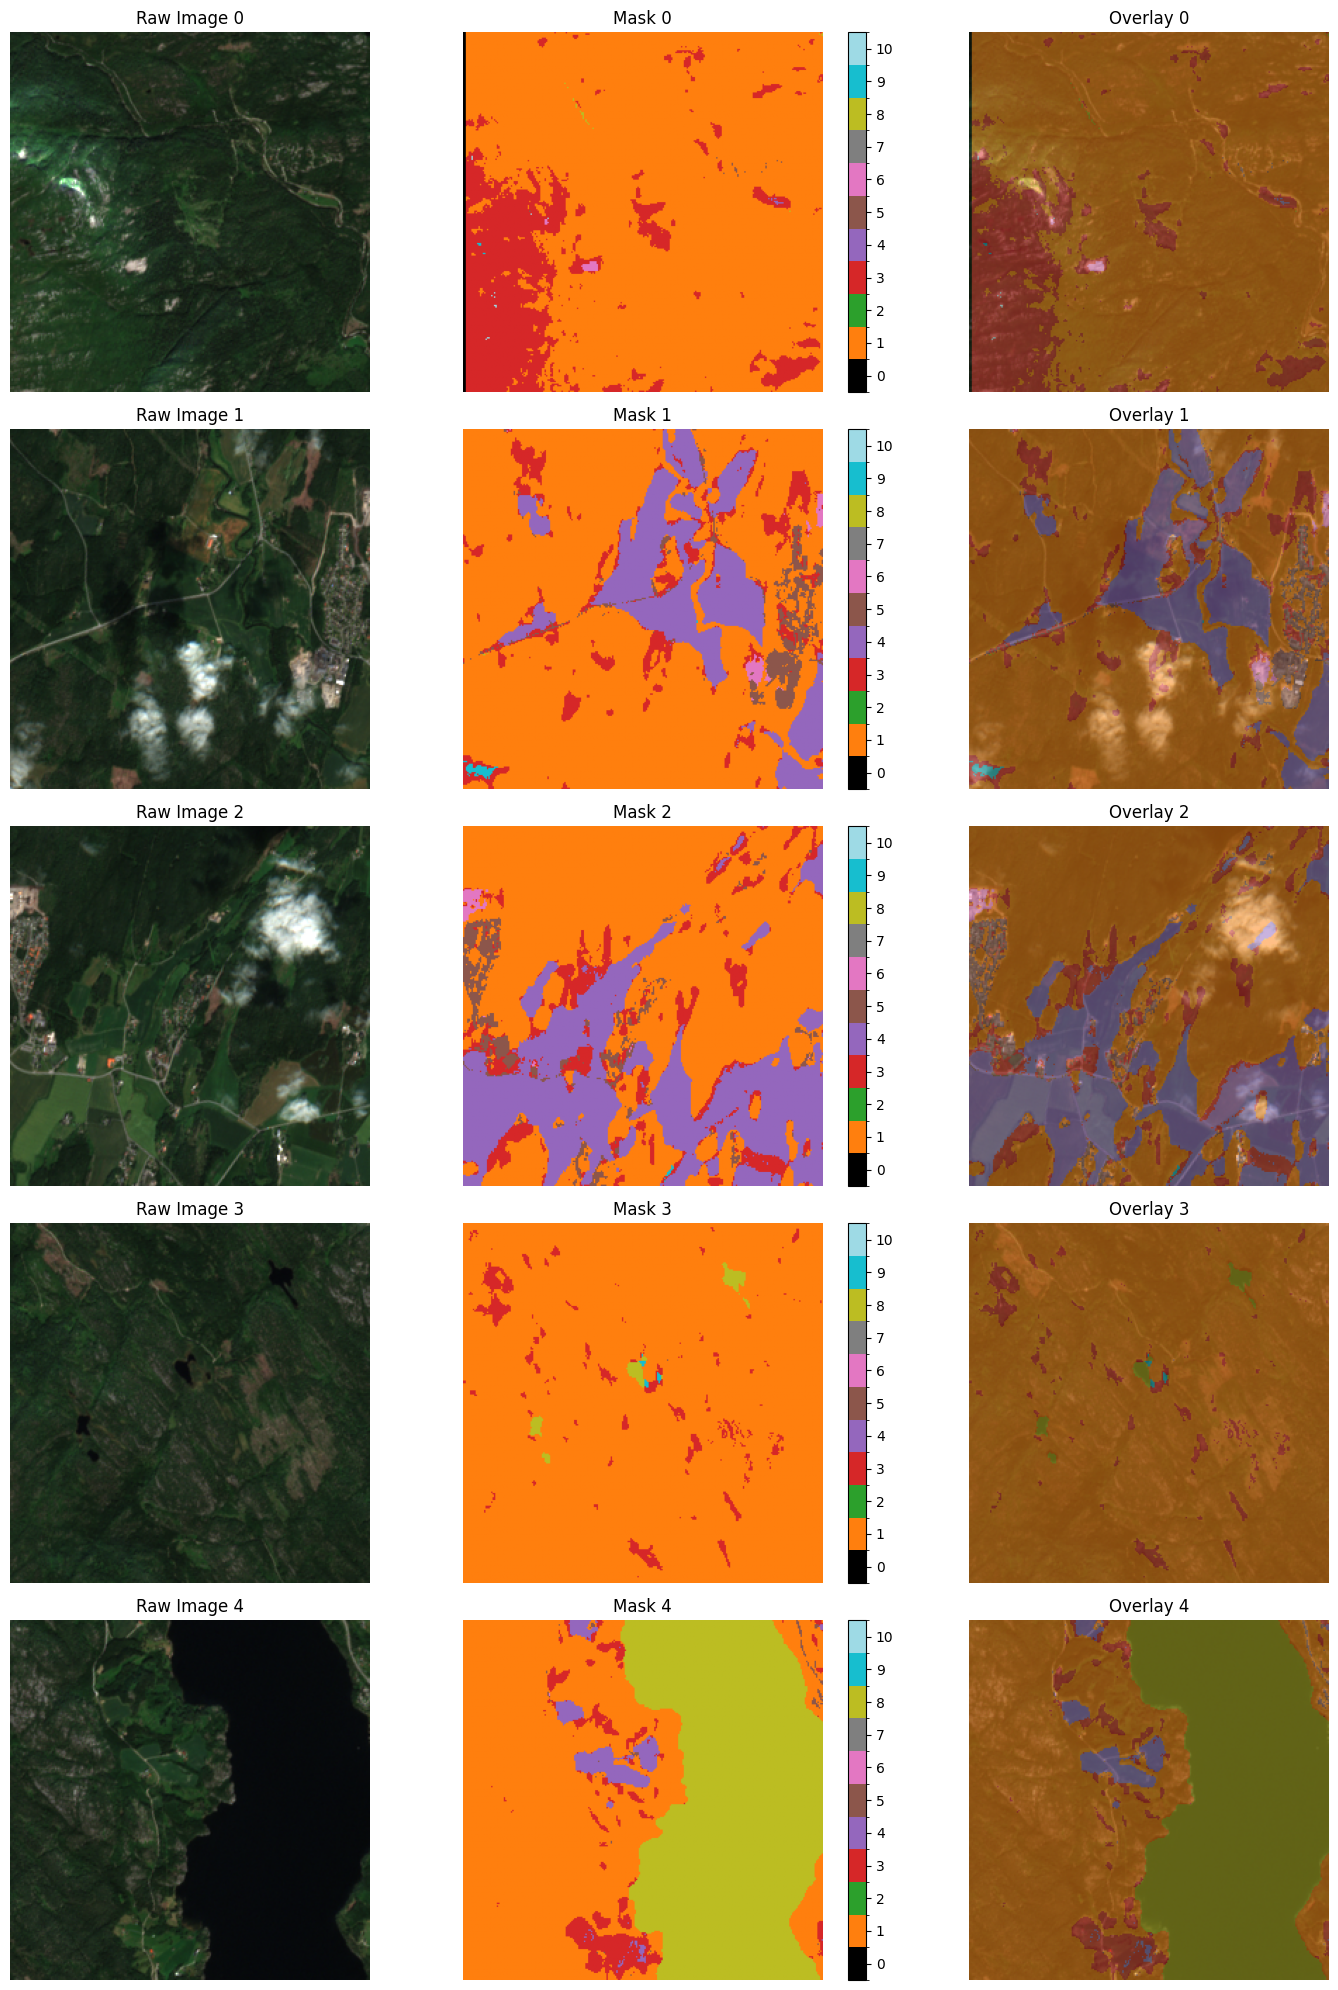

In [10]:
# Problem 1.2 — Visualise at least 5 image–mask pairs
# Determine unique class codes and create mapping
all_unique_mask_values = set()
for i in range(len(ds['train'])):
    mask_sample = np.array(ds['train'][i]['mask'])
    all_unique_mask_values.update(np.unique(mask_sample))
original_class_codes = sorted(list(all_unique_mask_values))
class_code_mapping = {code: i for i, code in enumerate(original_class_codes)}
num_classes = len(original_class_codes)

print(f"Original class codes found: {original_class_codes}")
print(f"Mapped to contiguous indices: {list(class_code_mapping.values())}")

# Define a consistent colormap
colors = plt.cm.get_cmap('tab20', num_classes)
color_list = [colors(i) for i in range(num_classes)]
if 0 in original_class_codes and original_class_codes[0] == 0:
    color_list[class_code_mapping[0]] = (0, 0, 0, 1) # Set class 0 to black
cmap = mcolors.ListedColormap(color_list)
norm = mcolors.BoundaryNorm(np.arange(num_classes + 1) - 0.5, cmap.N)

# Visualize 5 image-mask pairs
num_visualizations = 5
plt.figure(figsize=(15, num_visualizations * 4))
for i in range(num_visualizations):
    sample = ds['train'][i] # Use direct index for simplicity
    image = np.array(sample['image'])
    mask = np.array(sample['mask'])
    mask_remapped = np.vectorize(class_code_mapping.get)(mask)

    # Raw Image
    plt.subplot(num_visualizations, 3, i * 3 + 1)
    plt.imshow(image)
    plt.title(f"Raw Image {i}")
    plt.axis('off')

    # Segmentation Mask
    plt.subplot(num_visualizations, 3, i * 3 + 2)
    plt.imshow(mask_remapped, cmap=cmap, norm=norm)
    plt.title(f"Mask {i}")
    plt.colorbar(ticks=range(num_classes)) # Simpler colorbar
    plt.axis('off')

    # Overlay
    alpha = 0.5
    image_norm = image.astype(np.float32) / 255.0
    colored_mask_rgb = cmap(mask_remapped)[:, :, :3]
    overlay_image = (1 - alpha) * image_norm + alpha * colored_mask_rgb
    overlay_image = np.clip(overlay_image, 0, 1)

    plt.subplot(num_visualizations, 3, i * 3 + 3)
    plt.imshow(overlay_image)
    plt.title(f"Overlay {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()


Calculating pixel counts across the training dataset...


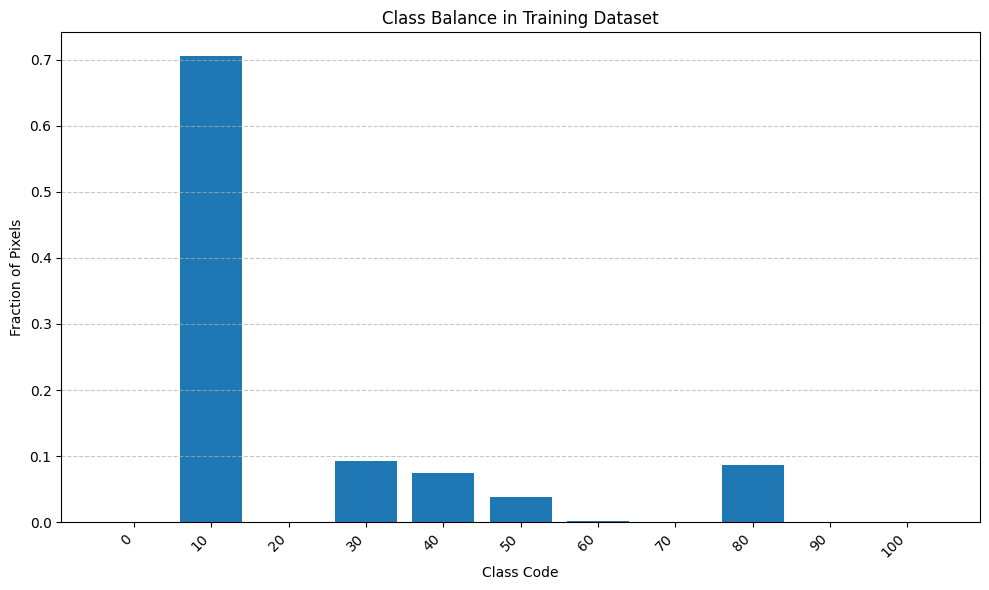


Class Pixel Fractions:
Class 0: 0.0002
Class 10: 0.7062
Class 20: 0.0000
Class 30: 0.0927
Class 40: 0.0738
Class 50: 0.0378
Class 60: 0.0018
Class 70: 0.0000
Class 80: 0.0861
Class 90: 0.0008
Class 100: 0.0006


In [17]:
# Problem 1.3 — Compute and plot class balance

# Initialize a counter for each class
pixel_counts = np.zeros(num_classes, dtype=int)
total_pixels = 0

print("Calculating pixel counts across the training dataset...")
for i in range(len(ds['train'])):
    mask = np.array(ds['train'][i]['mask'])
    mask_remapped = np.vectorize(class_code_mapping.get)(mask)

    # Count pixels for each class in the current mask
    counts_in_mask = np.bincount(mask_remapped.flatten(), minlength=num_classes)
    pixel_counts += counts_in_mask
    total_pixels += mask.size

# Calculate class frequencies
class_frequencies = pixel_counts / total_pixels

# Plotting the class balance
plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), class_frequencies, tick_label=[str(code) for code in original_class_codes])
plt.xlabel('Class Code')
plt.ylabel('Fraction of Pixels')
plt.title('Class Balance in Training Dataset')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nClass Pixel Fractions:")
for i, freq in enumerate(class_frequencies):
    print(f"Class {original_class_codes[i]}: {freq:.4f}")


#### Discussion (Problem 1.3)

The class balance analysis reveals a significant imbalance in the dataset, with Class 10 (likely 'water' or 'background') comprising over 70% of all pixels, while several other classes (e.g., 0, 20, 70) are extremely rare, some even having zero presence in the sampled masks. This severe imbalance can lead to a classifier that is heavily biased towards the majority class, performing poorly on minority classes. During training, the model might optimize for overall pixel accuracy by predominantly predicting the majority class, neglecting the under-represented classes entirely. This necessitates using techniques like inverse-frequency class weighting in the loss function to give more importance to the rare classes and encourage the model to learn their features.

In [18]:
# Problem 1.4 — Build PyTorch Dataset and DataLoader
# Ensure ds, class_code_mapping, and num_classes are available from previous steps

# Define target image size (divisible by 8)
IMG_SIZE = 256 # Original size is 256x256, which is divisible by 8

class SatelliteSegmentationDataset(Dataset):
    def __init__(self, hf_dataset_split, class_map, target_size=IMG_SIZE):
        self.hf_dataset = hf_dataset_split
        self.class_map = class_map

        # Image transformations
        self.image_transform = transforms.Compose([
            transforms.Resize((target_size, target_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # Mask transformations (nearest neighbor interpolation)
        self.mask_transform = transforms.Compose([
            transforms.Resize((target_size, target_size), interpolation=Image.NEAREST),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image']  # PIL Image
        mask = item['mask']    # PIL Image (L mode)

        # Apply image transformations
        image_tensor = self.image_transform(image)

        # Apply mask transformations and remap class codes
        mask_tensor = self.mask_transform(mask)

        # Convert mask to numpy array first to apply vectorization
        mask_np = mask_tensor.squeeze().numpy() # Remove channel dimension
        mask_remapped = np.vectorize(self.class_map.get)(mask_np)

        # Convert back to tensor, ensure int64 type and correct shape (H, W)
        mask_tensor = torch.from_numpy(mask_remapped).long() # .long() for int64

        return image_tensor, mask_tensor

# Split data into 80% training and 20% validation sets
train_size = int(0.8 * len(ds['train']))
val_size = len(ds['train']) - train_size

hf_train_split, hf_val_split = random_split(ds['train'], [train_size, val_size])

# Create Dataset instances
train_dataset = SatelliteSegmentationDataset(hf_train_split, class_code_mapping, IMG_SIZE)
val_dataset = SatelliteSegmentationDataset(hf_val_split, class_code_mapping, IMG_SIZE)

# Create DataLoader instances
BATCH_SIZE = 16 # You can adjust this batch size
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of validation batches: {len(val_dataloader)}")


Training dataset size: 632
Validation dataset size: 158
Number of training batches: 40
Number of validation batches: 10


---

## Problem 2: Model design and implementation (25 points)

Design and implement a convolutional segmentation model of your choice. Your model must:

- Accept a `(B, 3, H, W)` batch of images and produce a `(B, C, H, W)` tensor of per-pixel class logits.
- Consist entirely of convolutional operations (no fully connected layers that collapse spatial dimensions).

You have freedom in the specific architecture. Two natural options are:

- A **U-Net**-style encoder–decoder with skip connections, which explicitly preserves spatial detail through the network.
- A **ResNet**-style backbone with a lightweight decoder head, which benefits from the residual connections that ease gradient flow in deeper networks.

Whatever you choose, you must justify your architectural decisions in a short written discussion (3–5 sentences): why is this architecture appropriate for a segmentation task compared to a standard classification CNN? What role do skip connections or residual connections play?

Report the total number of trainable parameters in your model.

In [ ]:
# Problem 2 — Model definition


In [ ]:
# Problem 2 — Report total trainable parameters


#### Architectural discussion (Problem 2)

*Your answer here (3–5 sentences).*

---

## Problem 3: Training (25 points)

Train your model for at least 20 epochs using the following specifications:

**Loss function:** Use **pixel-wise cross-entropy loss** (`nn.CrossEntropyLoss`), which accepts the raw logit tensor of shape `(B, C, H, W)` and an integer mask of shape `(B, H, W)`. Because the class distribution is unequal, compute **inverse-frequency class weights**:

$$w_c = \frac{\text{total pixels}}{C \times \text{pixels of class } c}$$

and pass them to the `weight` argument of `CrossEntropyLoss`.

**Optimiser:** Use Adam or AdamW with a learning rate of your choice. You may additionally use a learning rate scheduler (e.g., `ReduceLROnPlateau` or cosine annealing).

**Produce the following plots:**
- Training loss and validation loss vs. epoch on the same axes.
- Validation mean IoU vs. epoch.

Discuss in 2–3 sentences: does your model appear to overfit? What evidence supports your conclusion?

In [ ]:
# Problem 3 — Loss function, optimiser, and training loop


In [ ]:
# Problem 3 — Plot training/validation loss and validation mIoU vs. epoch


#### Discussion (Problem 3)

*Your answer here (2–3 sentences).*

---

## Problem 4: Evaluation and interpretation (30 points)

### 4a. Quantitative evaluation

Evaluate your trained model on the validation set and report:

1. The **mean Intersection over Union (mIoU)**, defined as:

$$\text{mIoU} = \frac{1}{C} \sum_{c=0}^{C-1} \frac{\text{TP}_c}{\text{TP}_c + \text{FP}_c + \text{FN}_c}$$

where $\text{TP}_c$, $\text{FP}_c$, $\text{FN}_c$ are the true positives, false positives, and false negatives for class $c$ across the entire validation set.

2. A **per-class IoU bar chart** showing the IoU for each class individually, with a horizontal dashed line marking the mIoU. Label each bar with its class code.

3. Discuss: which classes does your model struggle with most? Does this correlate with the class frequencies you computed in Problem 1? (3–4 sentences)

In [ ]:
# Problem 4a — Compute mIoU and per-class IoU on the validation set


In [ ]:
# Problem 4a — Per-class IoU bar chart


#### Discussion (Problem 4a)

*Your answer here (3–4 sentences).*

### 4b. Qualitative evaluation

Visualise predictions for at least 4 validation samples. For each sample show:
- The input satellite image (with normalisation undone for display).
- The ground-truth mask.
- The predicted mask, with the per-sample mIoU printed in the title.

Identify and discuss one example where the model succeeds and one where it fails. What spatial or spectral features might explain the failure? (3–4 sentences)

In [ ]:
# Problem 4b — Qualitative visualisation of validation predictions


#### Discussion (Problem 4b)

*Your answer here (3–4 sentences).*

### 4c. Reflection

Answer the following questions in a short paragraph (4–6 sentences total):

- IoU is preferred over pixel accuracy for segmentation. Explain why, using the class balance you computed in Problem 1 as a concrete example.
- How would you expect model performance to change if you used a pretrained encoder (e.g., a ResNet backbone pretrained on ImageNet) instead of training from scratch? Why might pretrained features transfer usefully from natural images to satellite imagery despite the domain shift?

#### Reflection (Problem 4c)

*Your answer here (4–6 sentences).*